# Valutazione file iniziale

## IMPORT

In [9]:
from dl_client import DatalakeClient
import pandas as pd

client = DatalakeClient()

## Ricerca file

In [10]:
search = client.query_files(query={'custom.level': 'raw', 'custom.file_code': ['FUJIREBIOABETA']})
files = [x['filename'] for x in search['included_files']]
print(len(files))# Print the number of files found

1


In [11]:
print(files)

['FUJIREBIOABETA_11Aug2025.csv']


## Download zip file trovati

In [12]:
zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)



## Apertura singoli file

In [13]:
file_name = list(zip_files.keys())[0]
print(file_name)
dataset = zip_files[file_name]

df_new = dataset.copy(deep=True)
df_new.head()

FUJIREBIOABETA_11Aug2025.csv


,RID,VISCODE,VISCODE2,EXAMDATE,GUSPECID,VID,DRAWDTE,DER,SITE,VOL,RECDTE,STORDTE,RUN,RUNDATE,ABETA42,ABETA40,ABETA42_40,COMMENTS,update_stamp
0,42,v06,m60,2011-04-14,JA8075FB-05,9.0,2011-04-14,CSF,D023,0.35,2011-04-15,2011-07-22,2,2019-11-21,1022,10468.0,0.098,NaN,2020-02-07 11:12:44.0
1,51,v06,m72,2011-08-11,JA807VJD-04,9.0,2011-08-11,CSF,D099,0.20,2011-11-02,2011-11-03,6,2019-11-21,102,NaN,NaN,Not enough volume for 1-40,2020-02-07 11:12:44.0
2,89,m48,m48,2010-09-28,JA807JJG-04,8.0,2010-09-28,CSF,D073,0.35,2010-09-30,2011-08-25,6,2019-11-21,923,9201.0,0.100,NaN,2020-02-07 11:12:44.0
3,118,m60,m60,2011-02-16,BA8075HL-03,9.0,2011-02-16,CSF,D027,0.35,2011-02-17,2011-07-22,2,2019-11-21,885,9536.0,0.093,NaN,2020-02-07 11:12:44.0
4,126,m60,m60,2011-03-17,JA8075G8-04,9.0,2011-03-17,CSF,D023,0.35,2011-03-18,2011-07-22,2,2019-11-21,487,10189.0,0.048,NaN,2020-02-07 11:12:44.0


In [14]:
df_new.keys()

Index(['RID', 'VISCODE', 'VISCODE2', 'EXAMDATE', 'GUSPECID', 'VID', 'DRAWDTE',
       'DER', 'SITE', 'VOL', 'RECDTE', 'STORDTE', 'RUN', 'RUNDATE', 'ABETA42',
       'ABETA40', 'ABETA42_40', 'COMMENTS', 'update_stamp'],
      dtype='object')

In [8]:
df_new['POOL'].unique()

array([nan, 'ADNI Pool AD', 'ADNI Pool Normal'], dtype=object)

## conto soggetti e soggetti con 2+ visits

In [15]:
tot_sub = len(df_new['RID'].unique())
print('totale subject:', tot_sub)
multiple_visists = (df_new['RID'].value_counts() > 1).sum()
print('subjects with multiple visits: ', multiple_visists)

totale subject: 423
subjects with multiple visits:  1


In [16]:
df_new

,RID,VISCODE,VISCODE2,EXAMDATE,GUSPECID,VID,DRAWDTE,DER,SITE,VOL,RECDTE,STORDTE,RUN,RUNDATE,ABETA42,ABETA40,ABETA42_40,COMMENTS,update_stamp
0,42,v06,m60,2011-04-14,JA8075FB-05,9.0,2011-04-14,CSF,D023,0.35,2011-04-15,2011-07-22,2,2019-11-21,1022,10468.0,0.098,NaN,2020-02-07 11:12:44.0
1,51,v06,m72,2011-08-11,JA807VJD-04,9.0,2011-08-11,CSF,D099,0.20,2011-11-02,2011-11-03,6,2019-11-21,102,NaN,NaN,Not enough volume for 1-40,2020-02-07 11:12:44.0
2,89,m48,m48,2010-09-28,JA807JJG-04,8.0,2010-09-28,CSF,D073,0.35,2010-09-30,2011-08-25,6,2019-11-21,923,9201.0,0.100,NaN,2020-02-07 11:12:44.0
3,118,m60,m60,2011-02-16,BA8075HL-03,9.0,2011-02-16,CSF,D027,0.35,2011-02-17,2011-07-22,2,2019-11-21,885,9536.0,0.093,NaN,2020-02-07 11:12:44.0
4,126,m60,m60,2011-03-17,JA8075G8-04,9.0,2011-03-17,CSF,D023,0.35,2011-03-18,2011-07-22,2,2019-11-21,487,10189.0,0.048,NaN,2020-02-07 11:12:44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,999999,nv,nv,NaN,ADNI Pool 56 AD,NaN,NaN,NaN,NaN,0.35,NaN,NaN,8,2019-11-25,618,7773.0,0.080,NaN,2020-02-07 11:12:45.0
438,999999,nv,nv,NaN,ADNI Pool 59 Normal,NaN,NaN,NaN,NaN,0.35,NaN,NaN,9,2019-11-25,368,8642.0,0.043,NaN,2020-02-07 11:12:45.0
439,999999,nv,nv,NaN,ADNI Pool 56 AD,NaN,NaN,NaN,NaN,0.35,NaN,NaN,9,2019-11-25,627,8273.0,0.076,NaN,2020-02-07 11:12:45.0
440,999999,nv,nv,NaN,ADNI Pool 59 Normal,NaN,NaN,NaN,NaN,0.35,NaN,NaN,10,2019-11-26,381,8462.0,0.045,NaN,2020-02-07 11:12:45.0


## range alcune variabili

In [49]:
var_interesse = ['BETA_AMYLOID_1_40', 'BETA_AMYLOID_1_42', 'BETA_AMYLOID_42_40']
df_interesse= df_new[var_interesse]
df_interesse.head()

,BETA_AMYLOID_1_40,BETA_AMYLOID_1_42,BETA_AMYLOID_42_40
0,7324.79,264.01,0.036043
1,8431.15,1184.28,0.140465
2,8454.41,772.85,0.091414
3,9887.33,580.35,0.058696
4,9835.15,918.71,0.093411


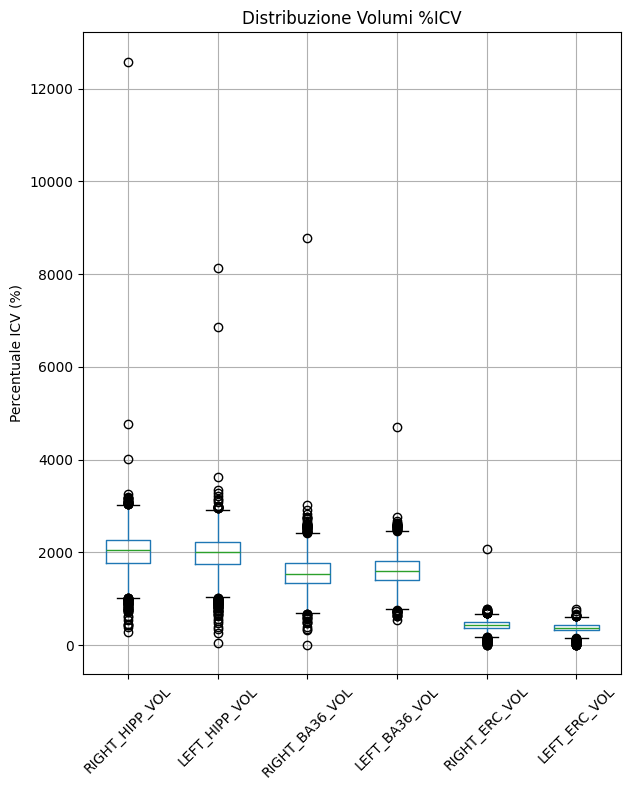

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione del plot
plt.figure(figsize=(12, 8))

# Box plot per le percentuali ICV



plt.subplot(1, 2, 2)
df_interesse.boxplot(rot=45)
plt.title('Distribuzione Volumi %ICV')
plt.ylabel('Percentuale ICV (%)')

plt.tight_layout()
plt.show()

In [ ]:
# Calcolo del 1° e 99° percentile per ciascun volume ICV
print("=== 1° E 99° PERCENTILE PER VARIABILI %ICV ===")
print()

percentiles = [1, 99]

# Creazione di un DataFrame con i percentili per una visualizzazione più chiara
percentile_df = pd.DataFrame(index=var_interesse, columns=['1° percentile', '99° percentile'])
for var in  var_interesse:
    percentile_df.loc[var, '1° percentile'] = df_interesse[var].quantile(0.01)
    percentile_df.loc[var, '99° percentile'] = df_interesse[var].quantile(0.99)

print("=== TABELLA RIASSUNTIVA ===")
percentile_df.round(6)

=== 1° E 99° PERCENTILE PER VARIABILI %ICV ===

=== TABELLA RIASSUNTIVA ===


,1° percentile,99° percentile
RIGHT_HIPP_VOL,965.82553,2927.34084
LEFT_HIPP_VOL,912.3652,2828.11126
RIGHT_BA36_VOL,813.95005,2439.15625
LEFT_BA36_VOL,851.2936,2411.67038
RIGHT_ERC_VOL,170.11728,656.35116
LEFT_ERC_VOL,143.3302,571.53336
ICV,1137452.72284,1810874.34698


#  Check metadata di tutti i file uno per uno

In [ ]:
i =9

In [21]:
file_name = 'UPENNBIOMKADNIDIAN2017_09Oct2025.csv' #files[0]
print(file_name, '----------')
metadata = client.get_metadata(object_name='raw/'+file_name)
display(metadata['metadata']['custom'])
i += 1

UPENNBIOMKADNIDIAN2017_09Oct2025.csv ----------


{'download_type': 'study_files',
 'file_code': 'UPENNBIOMK_ADNIDIAN_ES_2017',
 'level': 'raw',
 'population': ['1', 'GO', '2'],
 'source': 'ADNI'}

NameError: name 'i' is not defined

In [31]:
zip_files = client.download_file(object_name='raw/'+file_name,  
    extract_zip=True
)

In [4]:
file_code = 'ADNIMERGE'
search = client.query_files(
    query={
        'custom.level' : 'cleaned_01',
        'custom.file_code': file_code
    }
)

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True
)


In [15]:
file_name = list(zip_files.keys())[0]
dataset = zip_files[file_name]
zip_files

,RID,VISCODE,EXAMDATE,VERSION,IMAGE_UID,RUNDATE,STATUS,CBICA_ID,DATE,R702,...,R199,R200,R201,R202,R203,R204,R205,R206,R207,update_stamp
0,2,sc,2005-08-26,2016-03-21,I35475,2016-03-21,COMPLETE,011_S_0002_2005-08-26,2005-08-26,1784710,...,12577.70,7531.16,6862.94,8957.96,9767.36,3077.59,2563.72,1338.330,1044.690,2016-06-02 09:02:36.0
1,3,sc,2005-09-01,2016-03-21,I32237,2016-03-21,COMPLETE,011_S_0003_2005-09-01,2005-09-01,1785950,...,9596.26,6754.81,5647.18,8133.22,7992.18,3008.82,3520.32,1148.990,1203.530,2016-06-02 09:02:36.0
2,4,sc,2005-09-22,2016-03-21,I64631,2016-03-21,COMPLETE,022_S_0004_2005-09-22,2005-09-22,1619320,...,10444.50,7522.30,7652.39,8225.52,8943.81,2867.52,2141.69,1515.770,1755.200,2016-06-02 09:02:36.0
3,5,sc,2005-09-02,2016-03-21,I32246,2016-03-21,COMPLETE,011_S_0005_2005-09-02,2005-09-02,1655680,...,10243.40,5616.39,5902.29,8467.85,7683.51,2973.72,2405.68,1724.790,1643.910,2016-06-02 09:02:36.0
4,6,sc,2005-11-15,2016-03-21,I33025,2016-03-21,COMPLETE,100_S_0006_2005-11-15,2005-11-15,1528520,...,8364.14,5948.50,6253.38,5931.44,6659.54,2321.83,2245.08,1261.120,1250.460,2016-06-02 09:02:36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
835,1425,sc,2007-08-06,2016-03-21,I73357,2016-03-21,COMPLETE,041_S_1425_2007-08-06,2007-08-06,1360100,...,8223.08,6073.44,5872.55,6751.18,5906.35,3112.75,2164.66,1128.330,758.475,2016-06-02 09:02:38.0
836,1426,sc,2007-09-07,2016-03-21,I79102,2016-03-21,COMPLETE,137_S_1426_2007-09-07,2007-09-07,1612220,...,9022.20,5939.80,5302.83,6758.46,6978.18,1661.62,1788.38,944.368,1373.240,2016-06-02 09:02:38.0
837,1427,sc,2007-08-20,2016-03-21,I91126,2016-03-21,COMPLETE,127_S_1427_2007-08-20,2007-08-20,1552590,...,11428.10,6699.74,7530.97,9881.35,8473.67,3730.45,3510.70,1384.320,1608.320,2016-06-02 09:02:38.0
838,1430,sc,2007-09-07,2016-03-21,I79857,2016-03-21,COMPLETE,128_S_1430_2007-09-07,2007-09-07,1203100,...,7840.67,5337.89,5426.14,6072.02,6321.73,1960.17,1864.41,544.491,910.615,2016-06-02 09:02:38.0


In [ ]:

zip_files = client.download_file(
    search['object_name'],  
    extract_zip=True)

In [3]:
print(zip_files.keys())

dict_keys(['ADNIMERGE_06Jun2025.csv', 'MMSE_06Jun2025.csv', 'PTDEMOG_06Jun2025.csv', 'ADSP_PHC_BIOMARKER_06Jun2025.csv', 'BLCHANGE_06Jun2025.csv', 'DXSUM_06Jun2025.csv'])


In [14]:
file_name = 'ADNIMERGE_06Jun2025.csv'
df = zip_files[file_name]

NameError: name 'zip_files' is not defined

In [21]:
metadata = client.get_metadata(
            object_name = 'articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf'
        )
print(metadata['metadata'])

{'_id': '6838828ff99891d54bb44883', 'bucket_name': 'aind', 'content_type': 'application/pdf', 'created_at': '2025-05-29T15:51:43.525784', 'custom': {'author': 'Biel', 'keywords': ['ADNI', 'preclin', 'MCI', 'AD', 'imaging', 'Braak', 'staging', 'cogn', 'longit', 'predict'], 'year': '2021'}, 'filename': 'Biel_2021_ADNI_preclin_MCI_AD_imaging_Braak_staging_cogn_longit_predict.pdf', 'last_modified': '2025-05-29T15:51:43.443935', 'object_name': 'articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf', 'path': '/data/aind/articles/Biel 2021 ADNI preclin MCI AD imaging Braak staging cogn longit predict.pdf', 's3_url': 'http://131.175.204.159:9000/aind/articles/Biel%202021%20ADNI%20preclin%20MCI%20AD%20imaging%20Braak%20staging%20cogn%20longit%20predict.pdf?X-Amz-Algorithm=AWS4-HMAC-SHA256&X-Amz-Credential=admin%2F20250529%2Fus-east-1%2Fs3%2Faws4_request&X-Amz-Date=20250529T155143Z&X-Amz-Expires=3600&X-Amz-SignedHeaders=host&X-Amz-Signature=9d7b5fec764c2b503c460b66

In [6]:
df

,PTID,RID,COHORT,VISCODE,EXAMDATE,AGE,GENDER,EDUCAT,ETHNICITY,RACE,...,FAQ,MOCA,Ventricles,Hippocampus,Entorhinal,Fusiform,MidTemp,ICV,DX,AGE_bl
0,011_S_0002,2,ADNI1,0,2005-09-08,74.3,1,16,0.0,5.0,...,0.0,NaN,118233.0,8336.0,4177.0,16559.0,27936.0,1984660.0,0,74.3
1,011_S_0003,3,ADNI1,0,2005-09-12,81.3,1,18,0.0,5.0,...,10.0,NaN,84599.0,5319.0,1791.0,15506.0,18422.0,1920690.0,3,81.3
2,011_S_0003,3,ADNI1,6,2006-03-13,81.8,1,18,0.0,5.0,...,12.0,NaN,88580.0,5446.0,2427.0,14400.0,16972.0,1906430.0,3,81.3
3,011_S_0003,3,ADNI1,12,2006-09-12,82.3,1,18,0.0,5.0,...,17.0,NaN,90099.0,5157.0,1596.0,14617.0,17330.0,1903820.0,3,81.3
4,011_S_0003,3,ADNI1,24,2007-09-12,83.3,1,18,0.0,5.0,...,14.0,NaN,97420.0,5139.0,1175.0,14033.0,16398.0,1903420.0,3,81.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11453,168_S_6180,6180,ADNI3,66,2023-07-25,92.0,1,16,0.0,5.0,...,7.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,1,86.8
11454,135_S_6446,6446,ADNI3,60,2023-07-12,66.5,1,12,0.0,5.0,...,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,1,61.5
11455,041_S_6731,6731,ADNI3,48,2023-07-31,70.9,0,20,0.0,5.0,...,7.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,3,66.8
11456,035_S_6480,6480,ADNI3,60,2023-07-27,84.9,0,16,0.0,5.0,...,2.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,1,79.9
